# Regressão Linear

A regressão linear é o primeiro modelo de aprendizado de máquina que detalharemos neste curso. Ela é amplamente utilizada para prever valores numéricos com base em uma ou mais características. Por exemplo, podemos utilizá-la para prever o nível de satisfação de vida de uma população em função do PIB de um país.

Quando o modelo utiliza apenas uma variável independente, temos a regressão linear simples. Quando utiliza duas ou mais, temos a regressão linear múltipla.

## 1. Regressão Linear Simples

A regressão linear simples busca modelar a relação entre duas variáveis, $x$ e $y$, em que $y = f(x)$. A relação, neste caso, é dada por:

$$
y = \theta_0 + \theta_1 x + \epsilon
$$

em que:
* $x$ é a variável independente (também chamada de características ou features);
* $y$ é a variável dependente (valor no qual desejamos aproximar ou prever);
* $\theta_0$ é o coeficiente linear da reta (intercepto);
* $\theta_1$ é o coeficiente angular da reta;
* $\epsilon$ é o erro (ou resíduo) da aproximação. Por exemplo, imagine que você está tentando prever o gasto com alimentação de várias famílias com base na renda delas. O erro, neste caso, seria a diferença entre o que o modelo previu e o que a família realmente gastou.

### 1.1. Pressupostos do Modelo

Para trabalhar com a regressão linear simples, fazemos algumas suposições:

* *Linearidade*: a relação entre as variáveis $y$ e $x$ é linear ou aproximadamente linear;
* *Independência dos erros*: O segundo pressuposto é que os erros ($\epsilon$) são independentes entre si. Isso significa que o erro de uma
observação não deve depender do erro de outra observação.
* *Homocedasticidade*: a variância dos erros deve permanecer constante para todos os valores observados de $x$. Por exemplo, para o caso de prever o gasto com alimentação de várias famílias com base na renda delas, se o modelo for homoscedástico, o erro terá a mesma dispersão, independentemente de a família ser rica ou pobre.
* *Normalidade dos Erros*: os erros devem seguir uma distribuição normal.

### 1.2. Estimativa dos Parâmetros

O método mais comum para estimativa dos parâmetros $\theta_0$ e $\theta_1$ é o Método dos Mínimos Quadrados Ordinários. Neste caso, deveremos minimizar a soma dos quadrados das diferenças entre os valores observados de $y$ e os valores ajustados $\hat{y}$. Ou seja, queremos minimizar a função de erro definida como:

$$
J(\theta_0,\theta_1) = \sum_{i=0}^{N-1} \left(y^{(i)} - \hat{y}^{(i)}\right)^2
$$

em que $N$ é o número de amostras de treinamento do conjunto de treinamento dado por $\left\{x^{(i)},y^{(i)}\right\}_{i=0,1,...,N-1}$ e $\hat{y}^{(i)}$ é o valor previsto pelo modelo quando a entrada $x^{(i)}$ é aplicada, ou seja:

$$
\hat{y}^{(i)} = \hat{\theta}_0 + \hat{\theta}_1 x^{(i)}
$$

em que $\hat{\theta}_0$ e $\hat{\theta}_1$ são os valores previstos para $\theta_0$ e $\theta_1$, respectivamente. Portanto,

$$
J(\hat{\theta}_0,\hat{\theta}_1) = \sum_{i=0}^{N-1} \left(y^{(i)} - \left(\hat{\theta}_0 + \hat{\theta}_1 x^{(i)}\right)\right)^2
$$

Para encontrar o ponto de mínimo, calculamos a derivada parcial da função $J$ em relação a cada parâmetro e igualamos a zero. Para encontrar o $\hat{\theta}_0$ fazemos:

$$
\frac{\partial J}{\partial \hat{\theta}_0} = -2 \sum_{i=0}^{N-1} \left(y^{(i)} - \hat{\theta}_0 - \hat{\theta}_1 x^{(i)}\right) = 0
$$

Para encontrar o $\hat{\theta}_1$ fazemos:

$$
\frac{\partial J}{\partial \hat{\theta}_1} = -2 \sum_{i=0}^{N-1} x^{(i)} \left(y^{(i)} - \hat{\theta}_0 - \hat{\theta}_1 x^{(i)}\right) = 0
$$

A estimativa para o coeficiente angular $\hat{\theta}_1$ pode ser obtida pela fórmula:

$$
\hat{\theta}_1 = \frac{\displaystyle \sum_{i=0}^{N-1} \left(x^{(i)} - \bar{x}\right)\left(y^{(i)} - \bar{y}\right)}{\displaystyle \sum_{i=0}^{N-1} \left(x^{(i)} - \bar{x}\right)^2}
$$

em que $\bar{x}$ e $\bar{y}$ correspondem às médias dos conjuntos de dados $x$ e $y$, respectivamente. Após calcular $\hat{\theta}_1$, $\hat{\theta}_0$ pode ser determinado como:

$$
\hat{\theta}_0 = \bar{y} - \hat{\theta}_1 \bar{x}
$$

**Exemplo 1:** Desejamos realizar uma regressão linear para tentar prever uma medida quantitativa da progressão da diabetes um ano após o início do estudo. Para isso, vamos importar um conjunto de dados já disponível no banco ``sklearn.datasets``.

In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd

data = load_diabetes(as_frame=True, scaled=False)

Para ver as features, basta fazer:

In [2]:
print(data.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


* `age`: Idade (em anos)
* `sex`: Gênero
* `bmi`: Indice de massa corporal
* `bp`: Pressão sanguínea média
* `s1`: Colesterol total (tc)
* `s2`: Colesterol LDL (ldl)
* `s3`: Colesterol HDL (hdl)
* `s4`: Colesterol Total / HDL (tch)
* `s5`: Nível de triglicerídeos (ltg)
* `s6`: Nível de açucar no sangue (glu)
* `target`: Medida quantitativa da progressão da doença um ano após o início do estudo.

Vamos visualizar o dataframe fazendo uma cópia para ``df``:

In [3]:
df = data.frame.copy()
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.00,157.0,93.2,38.0,4.00,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.00,183.0,103.2,70.0,3.00,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.00,156.0,93.6,41.0,4.00,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.00,198.0,131.4,40.0,5.00,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.00,192.0,125.4,52.0,4.00,4.2905,80.0,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,60.0,2.0,28.2,112.00,185.0,113.8,42.0,4.00,4.9836,93.0,178.0
438,47.0,2.0,24.9,75.00,225.0,166.0,42.0,5.00,4.4427,102.0,104.0
439,60.0,2.0,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0,132.0
440,36.0,1.0,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0,220.0


Veja que existem várias features no nosso banco de dados. Vamos apresentar uma forma simples para selecionar qual freature possui maior importância para o nosso problema. No caso podemos utilizar o conceito de coeficiente de correlação. 

A correlação é uma medida estatística que indica a força e a direção da relação linear entre duas variáveis. No contexto da seleção de variáveis, as variáveis altamente correlacionadas com a variável dependente são consideradas mais relevantes. Além disso, variáveis que são fortemente correlacionadas entre si podem ser redundantes, o que justifica a remoção de uma delas.

O coeficiente de correlação de Pearson ($r$) mede a força e a direção da relação linear entre duas variáveis:
$$
r = \frac{\displaystyle \sum_i \left(x^{(i)} - \bar{x}\right)\left(y^{(i)} - \bar{y}\right)}{\displaystyle \sqrt{\sum_i \left(x^{(i)} - \bar{x}\right)^2 \sum_i \left(y^{(i)} - \bar{y}\right)^2}}
$$

Interpretação do valor (módulo):
* 0.0 a 0.3: Correlação desprezível ou fraca.
* 0.3 a 0.5: Correlação moderada.
* 0.5 a 0.7: Correlação forte (boa candidata para o modelo).
* 0.7 a 1.0: Correlação muito forte a perfeita.

Interpretação do sinal:
* Positivo (+): Se $x$ aumenta, $y$ também aumenta.
* Negativo (-): Se $x$ aumenta, $y$ diminui/

Podemos calcular o correlação utilizando o método `corr()` de um dataframe, selecionando as variáveis no qual desejamos calcular a correlação. Se desejamos realizar a correlação entre o `target` e a idade (`age`) fazemos:

In [4]:
# Correlação entre target e idade
corr = df[["target", "age"]].corr().iloc[0, 1]
corr

0.18788875071892003

Se desejamos realizar a correlação entre o `target` e a índice de massa corporal (`bmi`) fazemos:

In [5]:
# Correlação entre target e idade
corr = df[["target", "bmi"]].corr().iloc[0, 1]
corr

0.5864501344746885

Veja que a correlação é maior, indicando que o índice de massa corporal possui uma importância maior para explicar o problema. Podemos fazer a correlação de todas as variáveis com o `target` fazendo:

In [6]:
df.corr()["target"].drop("target")

age    0.187889
sex    0.043062
bmi    0.586450
bp     0.441482
s1     0.212022
s2     0.174054
s3    -0.394789
s4     0.430453
s5     0.565883
s6     0.382483
Name: target, dtype: float64

Veja que maior correlação é com índice de massa corporal (`bmi`), e portanto utilizaremos essa variável na regressão linear. Assim sendo, a variável $x$ indicará o índice de massa corporal (`bmi`) e a variável $y$ será a medida quantitativa da progressão da doença um ano após o início do estudo.

In [7]:
X = df[["bmi"]]
y = df["target"]

Podemos visualizar essas duas variáveis utilizando um gráfico de dispersão:

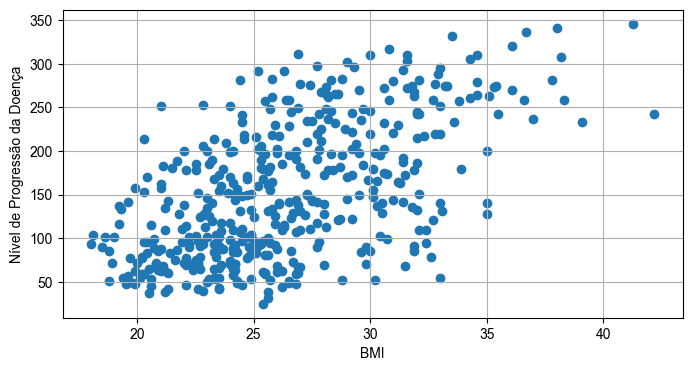

In [8]:
import matplotlib.pyplot as plt

#Muda a fonte dos Plots para Arial
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['mathtext.rm'] = "Arial"
plt.rcParams['mathtext.it'] = "Arial:italic"
plt.rcParams['mathtext.bf'] = "Arial:bold"
plt.rcParams['figure.figsize'] = (8, 4)

plt.scatter(X,y)
plt.ylabel('Nível de Progressão da Doença')
plt.xlabel('BMI')
plt.grid()
plt.show()

Vamos ajustar nosso modelo. Para isso, vamos dividir nosso conjunto de dados em dois sub-grupos: treinamento (que serão utilizados para ajustar os parâmetros) e teste (que será utilizado para verificar a capacidade de generalização do modelo). Para isso, vamos utilizar a função `train_test_split()`.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)

A estimativa para o coeficiente angular $\hat{\theta}_1$ pode ser obtida pela fórmula:

$$
\hat{\theta}_1 = \frac{\displaystyle \sum_{i=0}^{N-1} \left(x^{(i)} - \bar{x}\right)\left(y^{(i)} - \bar{y}\right)}{\displaystyle \sum_{i=0}^{N-1} \left(x^{(i)} - \bar{x}\right)^2}
$$

In [10]:
import numpy as np

# Há necessidade de conversão para um vetor na numpy em virtude dos dados originais serem um dataframe
Xdata = X_train.to_numpy()[:,0]
ydata = y_train.to_numpy().T

t1 = np.sum((Xdata - np.mean(Xdata))*(ydata - np.mean(ydata)))/np.sum((Xdata - np.mean(Xdata))**2)
t1

10.762790900604495

Após calcular $\hat{\theta}_1$, $\hat{\theta}_0$ pode ser determinado como:

$$
\hat{\theta}_0 = \bar{y} - \hat{\theta}_1 \bar{x}
$$

In [11]:
t0 = np.mean(ydata) - t1*np.mean(Xdata)
t0

-131.87377836094217

Assim sendo, a melhor curva que ajusta ao modelo é:

$$
y = 10,76x - 131,87
$$

Podemos plotar essa curva sobre o conjunto de dados e verificar a tendência de linearidade.

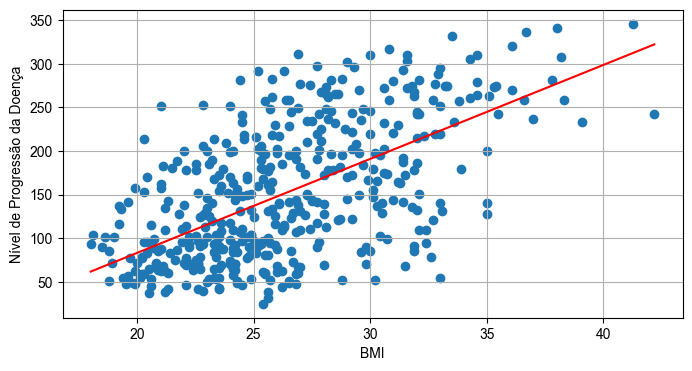

In [12]:
import numpy as np

X_curve = np.linspace(np.min(X),np.max(X),1000)
y_curve = t1*X_curve + t0

plt.scatter(X,y)
plt.plot(X_curve, y_curve,'r')
plt.ylabel('Nível de Progressão da Doença')
plt.xlabel('BMI')
plt.grid()
plt.show()

### 1.3. Utilização da `sklearn`

A `sklearn` possui as funções para ajuste dos parâmetros de regressão. É o que faremos no exemplo a seguir.

**Exemplo 2:** Vamos ajustar nosso modelo de regressão linear, porém utilizando funções prontas da biblioteca `sklearn`. Para isso, podemos utilizar o modelo `LinearRegression()` e utilizar o método `fit()` para ajustar os parâmetros do modelo.

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


O valor de $\theta_1$ é dado por:

In [14]:
t1 = model.coef_
t1

array([10.7627909])

O valor de $\theta_0$ é dado por:

In [15]:
t0 = model.intercept_
t0

-131.87377836094217

Que são os mesmos valores encontrados utilizando as fórmulas de regressão.

### 1.4. Diagnóstico e Avaliação do Modelo

Aavaliação e o diagnóstico de um modelo de regressão linear são essenciais para garantir a qualidade do modelo. Neste caso utilizamos os dados disponíveis no conjunto de teste. Para isso podemos utilizar as seguintes medidas:

* Erro quadrático médio (MSE):

$$
MSE = \frac{1}{N_T} \sum_{i=0}^{N_T - 1} \left(y^{(i)} - \widehat{y}^{(i)}\right)^2
$$

em que $N_T$ é o número total de pontos utilizado no conjunto de teste $\{x^{(i)}\, y^{(i)}\}_{i=0,1,...,N_T-1}$, $y^{(i)}$ é o valor real da variável dependente no conjunto de testes e $\hat{y}^{(i)}$ é o valor previsto pelo modelo quando a entrada $x^{(i)}$ é aplicada ao modelo.

* Coeficiente de Determinação ($R^2$): Indica a porcentagem da variação dos dados que o modelo explica. Vai de 0 a 1 (ou 0% a 100%). Um $R^2$ de 0,80 significa que seu modelo explica 80% da variabilidade dos dados.

A fórmula geral para o cálculo do $R^2$ é:
$$
R^2 = 1 - \frac{SQR}{SQT}
$$

Onde:
* $SQR$ (Soma dos Quadrados dos Resíduos): Representa a variação que o modelo não conseguiu explicar (a diferença entre os valores reais e os valores preditos).

$$
SQT = \sum_{i=0}^{N_T-1} \left(y^{(i)} - \bar{y}\right)^2
$$

tal que $y^{(i)}$ são os valores observados e $\bar{y}$ é a média desses valores.

* $SQT$ (Soma Total dos Quadrados): Representa a variação total dos dados em relação à média.

$$
SQR = \sum_{i=0}^{N_T-1} \left(y^{(i)} - \hat{y}^{(i)}\right)^2
$$

Podemos utilizar as funções `mean_squared_error()` e `r2_score()` da biblioteca `sklearn` para calcular esses valores.

**Exemplo 3:** Vamos determinar o erro quadrático médio e o coeficiente de determinação para o modelo de regressão linear obtido no exemplo anterior.

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

#O diagnóstico é sempre feito no conjunto de teste!
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro quadrático médio (MSE): {mse:.2f}")
print(f"Coeficiente de determinação (R²): {r2:.2f}")

Erro quadrático médio (MSE): 4061.83
Coeficiente de determinação (R²): 0.23


## 2. Regressão Linear Múltipla

O modelo de regressão linear múltipla é uma extensão do modelo de regressão linear simples, onde a variável dependente é explicada por mais de uma variável independente. Neste caso, o modelo é descrito como:

$$
y = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_p x_p + \epsilon
$$

em que:
* $x_1, x_2, \dots, x_p$ são as variáveis independentes (também chamada de características ou features);
* $y$ é a variável dependente (valor no qual desejamos aproximar ou prever);
* $\theta_0$ é o coeficiente linear da reta;
* $\theta_1, \theta_2, \dots, \theta_p$ são os coeficientes que representam o impacto de cada variável independente em $y$.
* $\epsilon$ é o erro (ou resíduo) da aproximação.

### 2.1. Pressupostos do Modelo

Para trabalhar com a regressão linear, fazemos algumas suposições:

* Assim como na regressão linear simples, é necessário linearidade, independência dos erros, homoscedasticidade e normalidade dos erros.
* *Exogeneidade das Variáveis Independentes:* as variáveis independentes ($x$) não devem ter nenhuma relação com o erro ($\epsilon$) do modelo, ou seja:
$$
E(\epsilon | X) = 0
$$
em que $E(\cdot | X)$ é a média condicional dado um valor $X$. Isso significa que, não importa o valor que $X$ assuma, a média dos erros deve ser sempre zero. Se houver uma correlação entre $X$ e o erro, dizemos que a variável é endógena.
* *Ausência de Multicolinearidade*: A multicolinearidade ocorre quando há alta correlação entre duas ou mais variáveis independentes no
modelo de regressão.

### 2.2. Estimativa dos Parâmetros

Assim como na regressão linear simples, para determinar os valores dos parâmetros do modelo, deveremos minimizar a soma dos quadrados das diferenças entre os valores observados de $y$ e os valores ajustados $\hat{y}$. A função de erro será:

$$
J(\mathbf{\Phi}) = \left(\mathbf{Y} - \mathbf{X}\mathbf{\Phi}\right)^T\left(\mathbf{Y} - \mathbf{X}\mathbf{\Phi}\right)
$$

em que:

* $\mathbf{Y}$ é o vetor coluna de observações da variável dependente de tamanho $(N \times 1)$;
* $\mathbf{X}$ é a matriz de delineamento de tamanho $(N \times (p+1))$, onde a primeira coluna é preenchida por $1$s (para o intercepto $\theta_0$) e as demais colunas são as observações das variáveis $x_1, \dots, x_p$;
* $\mathbf{\Phi}$ é o vetor de parâmetros $[\theta_0, \theta_1, \dots, \theta_p]^T$ de tamanho $((p+1) \times 1)$;

Para minimizar a função de custo $J(\mathbf{\Phi})$, derivamos a expressão em relação a $\mathbf{\Phi}$ e igualamos a zero. O resultado desse processo de otimização nos dá a chamada Equação Normal:

$$
\mathbf{\Phi} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}
$$

### 2.3. Normalização e Padronização

No contexto de regressão linear múltipla, as técnicas de normalização e padronização (*z-score*) são cruciais para garantir que o modelo seja treinado de forma eficiente e que seus coeficientes sejam interpretáveis.

Quando temos variáveis em escalas muito diferentes (ex: Área em m² variando de 50 a 500 e Número de Banheiros de 1 a 3), o modelo pode enfrentar dificuldades numéricas.

#### a) Padronização *z-score*

A padronização transforma os dados para que tenham média 0 e desvio padrão 1. É a técnica mais comum em modelos estatísticos. Neste caso, a variável normalizada é calculada como:

$$
z = \frac{x - \mu}{\sigma}
$$

em que $\mu$ é a média da variável e $\sigma$ é o desvio padrão da variável.

#### b) Normalização (*Min-Max Scaling*)

A normalização redimensiona os dados para um intervalo fixo, geralmente entre 0 e 1. Neste caso, a variável normalizada é calculada como:

$$
x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

em que $x_{min}$ e $x_{max}$ indicam, respectivamente, os valores mínimo e máximo da variável $x$. É útil quando você sabe que os dados possuem limites rígidos (ex: notas de 0 a 10) e quando a distribuição não é necessariamente normal (Gaussiana), porém é muito sensível a *outliers*. Se houver um valor extremamente alto, todos os outros dados serão "espremidos" perto do zero.

**Exemplo 4:** Desejamos realizar uma regressão linear múltipla para tentar prever uma medida quantitativa da progressão da diabetes um ano após o início do estudo. Para isso, vamos importar um conjunto de dados já disponível no banco ``sklearn.datasets``.

In [17]:
from sklearn.datasets import load_diabetes
import pandas as pd
data = load_diabetes(as_frame=True, scaled=False)

In [18]:
df = data.frame.copy()
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.00,157.0,93.2,38.0,4.00,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.00,183.0,103.2,70.0,3.00,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.00,156.0,93.6,41.0,4.00,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.00,198.0,131.4,40.0,5.00,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.00,192.0,125.4,52.0,4.00,4.2905,80.0,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,60.0,2.0,28.2,112.00,185.0,113.8,42.0,4.00,4.9836,93.0,178.0
438,47.0,2.0,24.9,75.00,225.0,166.0,42.0,5.00,4.4427,102.0,104.0
439,60.0,2.0,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0,132.0
440,36.0,1.0,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0,220.0


Vamos utilizar todas as variáveis para a regressão linear. Desta forma, as variáveis `X` e `y` são dadas como:

In [19]:
X = df.drop(columns=["target"])
y = df["target"]

Veja que as variáveis possuem ordem de grandezas muito diferentes entre si. Podemos realizar uma normalização ou padronização para melhorar o desempenho do nosso algoritmo de treinamento. Para esse caso vamos realizar uma normalização entre 0 e 1.

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler  = MinMaxScaler(feature_range=(0, 1))
scaled  = scaler.fit_transform(X)
df_scaled = pd.DataFrame(scaled, columns=X.columns)
df_scaled

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.666667,1.0,0.582645,0.549296,0.294118,0.256972,0.207792,0.282087,0.562217,0.439394
1,0.483333,0.0,0.148760,0.352113,0.421569,0.306773,0.623377,0.141044,0.222437,0.166667
2,0.883333,1.0,0.516529,0.436620,0.289216,0.258964,0.246753,0.282087,0.496578,0.409091
3,0.083333,0.0,0.301653,0.309859,0.495098,0.447211,0.233766,0.423131,0.572923,0.469697
4,0.516667,0.0,0.206612,0.549296,0.465686,0.417331,0.389610,0.282087,0.362385,0.333333
...,...,...,...,...,...,...,...,...,...,...
437,0.683333,1.0,0.421488,0.704225,0.431373,0.359562,0.259740,0.282087,0.605672,0.530303
438,0.466667,1.0,0.285124,0.183099,0.627451,0.619522,0.259740,0.423131,0.415810,0.666667
439,0.683333,1.0,0.285124,0.530563,0.318627,0.323705,0.272727,0.249647,0.305030,0.560606
440,0.283333,0.0,0.495868,0.464789,0.509804,0.416335,0.259740,0.393512,0.657026,0.409091


Após isso, vamos dividir nosso conjunto de dados em conjunto de treinamento e conjunto de validação.

In [21]:
from sklearn.model_selection import train_test_split

X = df_scaled
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=42
)

print(f"Tamanho do dataset = {X.shape[0]} amostras")
print(f"Quantidade de amostras de treinamento = {X_train.shape[0]} amostras")
print(f"Quantidade de amostras de teste = {X_test.shape[0]} amostras")

Tamanho do dataset = 442 amostras
Quantidade de amostras de treinamento = 309 amostras
Quantidade de amostras de teste = 133 amostras


E por fim, vamos utilizar o modelo de regressão linear disponibilizado na `sklearn`. Utilizaremos o mesmo método `fit()` para ajustar os parâmetros do modelo.

In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Os coeficientes $\theta_1, \theta_2, \dots, \theta_p$ podem ser determinados como:

In [23]:
theta = model.coef_
theta

array([   6.37597963,  -24.94631999,  142.49164186,   94.94103001,
       -253.17501262,  159.32689804,   34.34557573,   75.35836358,
        171.20845644,   11.31152349])

Já o coeficiente $\theta_0$ é obtido como:

In [24]:
theta_0 = model.intercept_
theta_0

-0.8873660950040119

Portanto, a equação que descreve esse modelo de regressão é dado como:

$$\begin{aligned}
\hat{y} = -0.8873 &+ 6.37x_1 - 24.94x_2 + 142.49x_3 + 94.94x_4 - 253.17x_5 \\
&+ 159.32x_6 + 34.34x_7 + 75.35x_8 + 171.20x_9 + 11.31x_{10}
\end{aligned}$$

$x_1, x_2, \dots, x_{10}$ representam as features na ordem em que aparecem no dataframe (idade, sexo, bmi, ...). Podemos agora determinar o erro quadrático médio e o coeficiente de determinação para essa regressão:

In [25]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro quadrático médio (MSE): {mse:.2f}")
print(f"Coeficiente de determinação (R²): {r2:.2f}")

Erro quadrático médio (MSE): 2821.75
Coeficiente de determinação (R²): 0.48


Por fim, vamos plotar um gráfico de dispersão que relaciona o valor previsto em função do valor real do conjunto de treinamento.

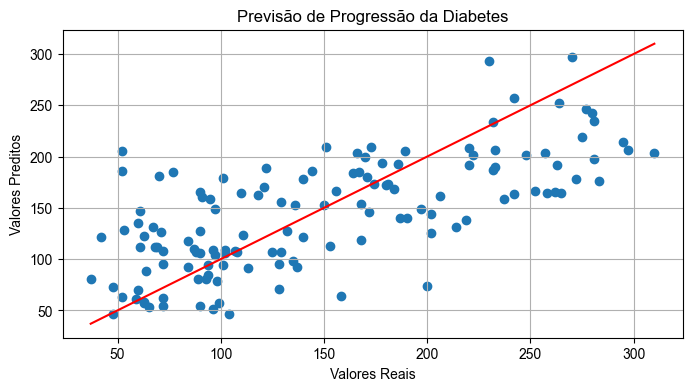

In [26]:
import matplotlib.pyplot as plt

y_test_min = np.min(y_test)
y_test_max = np.max(y_test)

y_ideal = np.linspace(y_test_min, y_test_max, 1000)

plt.plot(y_ideal, y_ideal, 'r')
plt.scatter(y_test, y_pred)
plt.xlabel("Valores Reais")
plt.ylabel("Valores Preditos")
plt.title("Previsão de Progressão da Diabetes")
plt.grid(True)
plt.show()

## 3. Regularização

Em modelos de regressão linear, o objetivo é minimizar a soma dos quadrados dos resíduos (erro). No entanto, se o modelo for muito complexo (muitas variáveis ou coeficientes muito altos), ele pode "decorar" o ruído dos dados de treino (*overfitting*).

A regularização adiciona uma penalidade ao tamanho dos coeficientes. Assim, o modelo é forçado a manter os pesos baixos, priorizando apenas as variáveis mais importantes.

### 3.1. Regularização Ridge (Regularização L2)

Na regularização Ridge, um termo $\frac{\alpha}{2} \sum_{i=1}^{p} \theta_i^2$ é adicionado à função de custo, ou seja, a função de erro a ser minimizada é:

$$
J_{\textrm{reg}}(\Phi) = J(\Phi) + \frac{\alpha}{2} \sum_{i=1}^{p} \theta_i^2
$$

Como os coeficientes são elevados ao quadrado, a penalidade cresce rapidamente para valores grandes dos coeficientes. No caso, $\alpha$ é um hiperparâmetro que ajuste a quantidade de regularização. Se $\alpha = 0$, a regularização é nula e temos uma regressão linear convencional. A equação normal para a regularização Ridge é:

$$
\mathbf{\Phi} = (\mathbf{X}^T\mathbf{X} + \alpha \mathbf{I})^{-1}\mathbf{X}^T\mathbf{Y}
$$

em que $\mathbf{I}$ é uma matriz identidade de dimensão $(p+1) \times (p+1)$.

### 3.2. Regularização Lasso (Regularização L1)

Na regularização Lasso, um termo $\alpha \sum_{i=1}^{p} |\theta_i|$ é adicionado à função de custo, ou seja, a função de erro a ser minimizada é:

$$
J_{\textrm{reg}}(\Phi) = J(\Phi) + \alpha \sum_{i=1}^{p} |\theta_i|
$$

A geometria da regularização $L_1$ possui "quinas" nos eixos. Isso faz com que, durante a otimização, muitos coeficientes sejam forçados a ser exatamente zero. É uma forma de seleção de variáveis.

Diferentemente da regularização $L_2$, a regularização Lasso (L1) não possui uma fórmula fechada (analítica) para estimativa dos coeficientes, sendo necessário um algoritmo recursivo para minimização da função de custo.

**Exemplo 5:** Desejamos realizar uma regressão linear múltipla com regularização para tentar prever uma medida quantitativa da progressão da diabetes um ano após o início do estudo. Para isso, vamos importar um conjunto de dados já disponível no banco `sklearn.datasets`.

Vamos inicialmente importar nosso conjunto de dados.

In [27]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

diabetes = load_diabetes(as_frame=True, scaled=False)
df = diabetes.frame.copy()
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


In [28]:
X, y = df.drop(columns=["target"]), df["target"]

scaler   = MinMaxScaler(feature_range=(0, 1))
scaled   = scaler.fit_transform(X)
X_scaled = pd.DataFrame(scaled, columns=X.columns)
X_scaled

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.666667,1.0,0.582645,0.549296,0.294118,0.256972,0.207792,0.282087,0.562217,0.439394
1,0.483333,0.0,0.148760,0.352113,0.421569,0.306773,0.623377,0.141044,0.222437,0.166667
2,0.883333,1.0,0.516529,0.436620,0.289216,0.258964,0.246753,0.282087,0.496578,0.409091
3,0.083333,0.0,0.301653,0.309859,0.495098,0.447211,0.233766,0.423131,0.572923,0.469697
4,0.516667,0.0,0.206612,0.549296,0.465686,0.417331,0.389610,0.282087,0.362385,0.333333
...,...,...,...,...,...,...,...,...,...,...
437,0.683333,1.0,0.421488,0.704225,0.431373,0.359562,0.259740,0.282087,0.605672,0.530303
438,0.466667,1.0,0.285124,0.183099,0.627451,0.619522,0.259740,0.423131,0.415810,0.666667
439,0.683333,1.0,0.285124,0.530563,0.318627,0.323705,0.272727,0.249647,0.305030,0.560606
440,0.283333,0.0,0.495868,0.464789,0.509804,0.416335,0.259740,0.393512,0.657026,0.409091


Criando o nosso conjunto de teste e de treinamento:

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Tamanho do dataset = {X.shape[0]} amostras")
print(f"Quantidade de amostras de treinamento = {X_train.shape[0]} amostras")
print(f"Quantidade de amostras de teste = {X_test.shape[0]} amostras")

Tamanho do dataset = 442 amostras
Quantidade de amostras de treinamento = 353 amostras
Quantidade de amostras de teste = 89 amostras


Vamos agora criar nossos modelos de regressão com regularização utilizando as funções `Ridge()` e `Lasso()`. Essas funções recebem, como argumento, o hiperparâmetro que controla a quantidade de regularização a ser aplicado no modelo.

In [30]:
ridge_regression = Ridge(alpha=1.5)
lasso_regression = Lasso(alpha=0.2)
linear_regression = LinearRegression()

ridge_regression.fit(X_train, y_train)
lasso_regression.fit(X_train, y_train)
linear_regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Podemos verificar os parâmetros gerados pelo processo de treinamento do modelo:

In [31]:
t0_ridge, t1_ridge = ridge_regression.intercept_, ridge_regression.coef_
t0_lasso, t1_lasso = lasso_regression.intercept_, lasso_regression.coef_
t0, t1 = linear_regression.intercept_, linear_regression.coef_

print(f"Regressão Linear: \n Intercepto (theta0) = {t0:.4f}")
print(f"Coeficientes (theta1...) = {t1}\n")

print(f"Ridge (L2): \n Intercepto = {t0_ridge:.4f}")
print(f"Coeficientes = {t1_ridge}\n")

print(f"Lasso (L1): \n Intercepto = {t0_lasso:.4f}")
print(f"Coeficientes = {t1_lasso}")

Regressão Linear: 
 Intercepto (theta0) = -9.0560
Coeficientes (theta1...) = [   8.2612689   -23.06446772  141.48197617   84.9935688  -261.46368693
  162.87932677   46.32729542   72.03113268  191.18672297   13.3055384 ]

Ridge (L2): 
 Intercepto = 45.6563
Coeficientes = [ 10.14102365 -22.09938025 130.20616812  79.64013615 -33.40940968
 -23.77740686 -53.21584567  41.84833258 101.76306148  21.60676166]

Lasso (L1): 
 Intercepto = 43.2035
Coeficientes = [  3.94789617 -19.99418015 143.84385211  79.86077649 -46.31102921
  -0.         -55.94409864  18.44951639 121.89921848  11.28275428]


E por fim, vamos calcular o coeficiente de determinação e o erro quadrático médio dos modelos:

In [32]:
y_pred_ridge = ridge_regression.predict(X_test)
y_pred_lasso = lasso_regression.predict(X_test)
y_pred_linear = linear_regression.predict(X_test)

print("--- Resultados Ridge (L2) ---")
print(f"R2 Score: {r2_score(y_test, y_pred_ridge):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_ridge):.4f}")

print("\n--- Resultados Lasso (L1) ---")
print(f"R2 Score: {r2_score(y_test, y_pred_lasso):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_lasso):.4f}")

print("\n--- Resultados Regressão Linear ---")
print(f"R2 Score: {r2_score(y_test, y_pred_linear):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_linear):.4f}")

--- Resultados Ridge (L2) ---
R2 Score: 0.4608
MSE: 2856.8407

--- Resultados Lasso (L1) ---
R2 Score: 0.4676
MSE: 2820.6255

--- Resultados Regressão Linear ---
R2 Score: 0.4526
MSE: 2900.1936


## Exercícios

1. Na equação da regressão linear, por que incluímos o termo de erro ($\epsilon$)? O que ele representa em termos de fatores que não estão no modelo?
2. Explique como o método dos mínimos quadrados ordinários permite uma boa estimativa para os parâmetros de um modelo de regressão linear.
3. Para que os estimadores de uma regressão linear sejam confiáveis, o modelo deve seguir certas suposições. Descreva pelo menos três delas (ex: linearidade, homocedasticidade, independência).
4. O que representa o coeficiente de determinação $R^2$ em um modelo de regressão? Por que um $R^2$ muito próximo de 1 nem sempre garante que o modelo fará boas previsões em novos dados?
5. A Regressão Ridge ($L_2$) adiciona um termo de penalidade à função de perda proporcional ao quadrado da magnitude dos coeficientes. Explique como esse método diminui a possibilidade de um overfitting.
6. Discuta o papel do parâmetro de regularização $\alpha$. O que acontece com o modelo quando $\alpha = 0$ e quando $\alpha \to \infty$?
7. Qual a importância de normalização ou padronização em um processo de regressão linear múltipla?
8. A Regressão Lasso ($L_1$) utiliza o valor absoluto dos coeficientes na penalidade. Qual a principal vantagem teórica do Lasso em relação à Ridge quando temos um modelo com muitas variáveis irrelevantes?